# **01 Data Loading**

In [1]:
import pandas as pd

# load each dataset and print the data range it covers
files = {
    "cases": "datasets/cases_malaysia.csv",
    "tests": "datasets/tests_malaysia.csv",
    "vax": "datasets/vax_malaysia.csv",
    "hospital": "datasets/hospital.csv",
    "icu": "datasets/icu.csv",
    "population": "datasets/population.csv",
}

dfs = {}
for name, path in files.items():
    df = pd.read_csv(path)
    dfs[name] = df
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"])
        print(f"{name:12s} rows={len(df):6d} date range={df['date'].min().date()} to {df['date'].max().date()}")
    else:
        print(f"{name:12s} rows={len(df):6d} no date column")

print()

for name, df in dfs.items():
    if "date" in df.columns:
        dupes = df["date"].duplicated().sum()
        print(f"{name:12s} {dupes} duplicate dates")

cases        rows=  1954 date range=2020-01-25 to 2025-05-31
tests        rows=  1955 date range=2020-01-24 to 2025-05-31
vax          rows=  1460 date range=2021-02-24 to 2025-02-22
hospital     rows= 29765 date range=2020-03-24 to 2025-05-31
icu          rows= 29605 date range=2020-03-24 to 2025-05-31
population   rows=    18 no date column

cases        0 duplicate dates
tests        0 duplicate dates
vax          0 duplicate dates
hospital     27874 duplicate dates
icu          27714 duplicate dates


Most files cover about 2020 to 2025 daily. The vax file starts later, on 2021-02-24, since that is when Malaysia's vaccination program began and population has no date column since it is a static per-state table used later for normalizing. Hospital and icu have far more rows than the rest as they include one row per state per day, so they will need to be filtered down to just the "Malaysia" row before merging later on.

In [2]:
# list the unique state values in hospital, icu and population
hospital = dfs["hospital"]
icu = dfs["icu"]
population = dfs["population"]

print("hospital states:", sorted(hospital["state"].unique()), "\n")
print("icu states:", sorted(icu["state"].unique()), "\n")
print("population states:", sorted(population["state"].unique()), "\n")

# confirm a "Malaysia" row exists for every date in hospital and icu
n_dates = hospital["date"].nunique()
malaysia_rows = (hospital["state"] == "Malaysia").sum()

print(f"hospital: {n_dates} unique dates, {malaysia_rows} Malaysia rows -> {'match' if n_dates == malaysia_rows else 'MISMATCH'}")

n_dates = icu["date"].nunique()
malaysia_rows = (icu["state"] == "Malaysia").sum()
print(f"icu: {n_dates} unique dates, {malaysia_rows} Malaysia rows -> {'match' if n_dates == malaysia_rows else 'MISMATCH'}")

hospital states: ['Johor', 'Kedah', 'Kelantan', 'Melaka', 'Negeri Sembilan', 'Pahang', 'Perak', 'Perlis', 'Pulau Pinang', 'Sabah', 'Sarawak', 'Selangor', 'Terengganu', 'W.P. Kuala Lumpur', 'W.P. Labuan', 'W.P. Putrajaya'] 

icu states: ['Johor', 'Kedah', 'Kelantan', 'Melaka', 'Negeri Sembilan', 'Pahang', 'Perak', 'Perlis', 'Pulau Pinang', 'Sabah', 'Sarawak', 'Selangor', 'Terengganu', 'W.P. Kuala Lumpur', 'W.P. Labuan', 'W.P. Putrajaya'] 

population states: ['Johor', 'Kedah', 'Kelantan', 'Klang Valley', 'Malaysia', 'Melaka', 'Negeri Sembilan', 'Pahang', 'Perak', 'Perlis', 'Pulau Pinang', 'Sabah', 'Sarawak', 'Selangor', 'Terengganu', 'W.P. Kuala Lumpur', 'W.P. Labuan', 'W.P. Putrajaya'] 

hospital: 1891 unique dates, 0 Malaysia rows -> MISMATCH
icu: 1891 unique dates, 0 Malaysia rows -> MISMATCH


hospital.csv and icu.csv have no national "Malaysia" row, only the 16 states/territories, across all 1891 dates. Therefore, national totals must be computed by summing all 16 state rows per date in step 4. population.csv does have a "Malaysia" row, but also a "Klang Valley" row, which is a multi-state region, not a real state, so it should be excluded from any state-level summation.

In [3]:
# aggregate hospital and icu to national totals by summing all states per date
hospital_national = hospital.groupby("date", as_index=False).sum(numeric_only=True)
icu_national = icu.groupby("date", as_index=False).sum(numeric_only=True)

# merge all national-level daily tables together on date
merged = dfs["cases"].merge(dfs["tests"], on="date", how="outer")
merged = merged.merge(dfs["vax"], on="date", how="outer")
merged = merged.merge(hospital_national, on="date", how="outer")
merged = merged.merge(icu_national, on="date", how="outer")
merged = merged.sort_values("date").reset_index(drop=True)


print(f"merged shape: {merged.shape}")
print(f"date range: {merged['date'].min().date()} -> {merged['date'].max().date()}")
merged.head()

merged shape: (1955, 108)
date range: 2020-01-24 -> 2025-05-31


,date,cases_new,cases_import,cases_recovered,cases_active,cases_cluster,cases_unvax,cases_pvax,cases_fvax,cases_boost,...,vent,vent_port,icu_covid,icu_pui,icu_noncovid,vent_covid,vent_pui,vent_noncovid,vent_used,vent_port_used
0,2020-01-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-25,4.0,4.0,0.0,4.0,0.0,4.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-26,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-01-27,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-01-28,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The merge produced 1955 rows spanning 2020-01-24 to 2025-05-31, one row per date, with 108 columns from all five files combined. NaNs appear early on because some files start later than others, for example icu and hospital data only begins 2020-03-24 and vax only begins 2021-02-24. These gaps will be handled in Phase 2 (cleaning).

# **02 Data Cleaning**

In [4]:
# check whether the merged table has a fully continuous daily date range
full_range = pd.date_range(merged["date"].min(), merged["date"].max(), freq="D")
missing_dates = full_range.difference(merged["date"])
print(f"{len(missing_dates)} missing dates out of {len(full_range)} expected\n")

# check how many NaNs each column has
pd.set_option("display.max_rows", None)
na_counts = merged.isna().sum()
na_counts = na_counts[na_counts > 0].sort_values(ascending=False)
print(na_counts)

0 missing dates out of 1955 expected

cluster_religious          1955
cluster_workplace          1955
cluster_community          1955
cluster_education          1955
cluster_detentionCentre    1955
cluster_import             1955
cluster_highRisk           1955
daily_booster2_adol         495
daily_booster               495
daily_partial_child         495
daily_full_child            495
daily_partial               495
daily_booster_adol          495
daily_full_adol             495
daily_partial_adol          495
daily                       495
daily_booster2              495
daily_full                  495
sinovac4                    495
sinovac3                    495
sinovac2                    495
sinovac1                    495
pfizer4                     495
pfizer3                     495
pfizer2                     495
pfizer1                     495
cumul_booster2_child        495
cumul_booster_child         495
cumul_full_child            495
cumul_partial_child         495
cu

In [5]:
# confirm all missing vax rows fall before vax reporting actually started
vax_missing_dates = merged.loc[merged["daily"].isna(), "date"]
print("vax missing dates range:", vax_missing_dates.min().date(), "to", vax_missing_dates.max().date())

# get the first and last date that vax.csv actually reports
vax_start = dfs["vax"]["date"].min()
vax_end = dfs["vax"]["date"].max()

# count how many missing vax rows fall before reporting started, after it eneded or genuinely in between
vax_before = (vax_missing_dates < vax_start).sum()
vax_after = (vax_missing_dates > vax_end).sum()
vax_between = len(vax_missing_dates) - vax_before - vax_after

print(f"vax missing before {vax_start.date()}: {vax_before}, after {vax_end.date()}: {vax_after}, in between: {vax_between}")

vax missing dates range: 2020-01-24 to 2025-05-31
vax missing before 2021-02-24: 397, after 2025-02-22: 98, in between: 0


In [6]:
# repeat the same check for hospital, using "beds" as the representative column
hosp_missing_dates = merged.loc[merged["beds"].isna(), "date"]
hosp_start = hospital["date"].min()
hosp_end = hospital["date"].max()

hosp_before = (hosp_missing_dates < hosp_start).sum()
hosp_after = (hosp_missing_dates > hosp_end).sum()
hosp_between = len(hosp_missing_dates) - hosp_before - hosp_after

print(f"hosp missing before {hosp_start.date()}: {hosp_before}, after {hosp_end.date()}: {hosp_after}, in between: {hosp_between}")

# repeat the same check for icu, using "beds_icu" as the representative column
icu_missing_dates = merged.loc[merged["beds_icu"].isna(), "date"]
icu_start = icu["date"].min()
icu_end = icu["date"].max()

icu_before = (icu_missing_dates < icu_start).sum()
icu_after = (icu_missing_dates > icu_end).sum()
icu_between = len(icu_missing_dates) - icu_before - icu_after

print(f"icu missing before {icu_start.date()}: {icu_before}, after {icu_end.date()}: {icu_after}, in between: {icu_between}")

hosp missing before 2020-03-24: 60, after 2025-05-31: 0, in between: 4
icu missing before 2020-03-24: 60, after 2025-05-31: 0, in between: 4


In [7]:
# find the specific dates where hospital data is missing inside its normal reporting window
hosp_between_dates = hosp_missing_dates[(hosp_missing_dates >= hosp_start) & (hosp_missing_dates <= hosp_end)]
print("hospital in between gap dates:", hosp_between_dates.dt.date.tolist())

# find the specific dates where icu data is missing inside its normal reporting window
icu_between_dates = icu_missing_dates[(icu_missing_dates >= icu_start) & (icu_missing_dates <= icu_end)]
print("icu in-between gap dates:", icu_between_dates.dt.date.tolist())

hospital in between gap dates: [datetime.date(2023, 11, 14), datetime.date(2024, 3, 6), datetime.date(2024, 3, 28), datetime.date(2024, 3, 31)]
icu in-between gap dates: [datetime.date(2023, 9, 22), datetime.date(2023, 11, 14), datetime.date(2024, 3, 6), datetime.date(2024, 3, 31)]


In [8]:
# show the values immediately before and after each hospital/icu gap to see which fill method fits better
for d in [pd.Timestamp("2023-11-14"), pd.Timestamp("2024-03-06"), pd.Timestamp("2024-03-28"), pd.Timestamp("2024-03-31"), pd.Timestamp("2023-09-22")]:
    idx = merged.index[merged["date"] == d]
    if len(idx):
        i = idx[0]
        print(d.date(), "before:", merged.loc[i-1, "beds_icu"], "after:", merged.loc[i+1, "beds_icu"])

2023-11-14 before: 795.0 after: 791.0
2024-03-06 before: 868.0 after: 886.0
2024-03-28 before: 876.0 after: 858.0
2024-03-31 before: 854.0 after: 870.0
2023-09-22 before: 845.0 after: 805.0


The data range has no gaps so every day between 2020-01-24 and 2025-05-31 is present. Most missing values line up with known file start dates rather than being scattered randomly. Vax's 495 missing rows are fully explained by dates before or after its reporting window, so filling them with 0 is safe. Hospital and icu each have 4 real gaps inside their normal reporting period, mostly but not fully overlapping between the two files, which suggests occasional one-day reporting outages. Checking the actual values before and after each gap showed one case with a meaningful 40-bed shift, so interpolating between the two neighboring days is more accurate than forward filling, which would have missed that change.

In [9]:
# drop 7 cluster columns that are entirely empty
empty_cols = ["cluster_religious", "cluster_workplace", "cluster_community",
              "cluster_education", "cluster_detentionCentre", "cluster_import",
              "cluster_highRisk"]
merged = merged.drop(columns=empty_cols)

# fill vax columns with 0
vax_cols = dfs["vax"].columns.drop("date")
merged[vax_cols] = merged[vax_cols].fillna(0)

# for hosp and icu: fill the pre-reporting-start gap with 0, then interpolate the few real in-between gaps
hosp_icu_cols = hospital_national.columns.drop("date").tolist() + icu_national.columns.drop("date").tolist()
before_hosp_start = merged["date"] < hosp_start
merged.loc[before_hosp_start, hosp_icu_cols] = merged.loc[before_hosp_start, hosp_icu_cols].fillna(0)
merged[hosp_icu_cols] = merged[hosp_icu_cols].interpolate(method="linear")

# fill the single pre-reporting cases row (2020-01-24) with 0
cases_cols = dfs["cases"].columns.drop("date").difference(empty_cols)
merged[cases_cols] = merged[cases_cols].fillna(0)

print(merged.isna().sum().sum(), "missing values remaining")

0 missing values remaining


In [10]:
# scan every numeric column for unusual day-to-day jumps, not just a hand-picked subset
numeric_cols = merged.select_dtypes(include="number").columns.drop("date", errors="ignore")

spike_summary = []
for col in numeric_cols:
    diffs = merged[col].diff()

    # set the cutoff at 4x the typical day-to-day change, so only extreme jumps count as spike
    threshold = diffs.std() * 4

    # count how many days had a change bigger than that cutoff, in either direction
    n_spikes = (diffs.abs() > threshold).sum()

    spike_summary.append((col, n_spikes))

spike_summary = pd.DataFrame(spike_summary, columns = ["column", "n_spikes"]).sort_values("n_spikes", ascending=False)
print(spike_summary)

                  column  n_spikes
37  daily_booster2_child        44
29                 daily        36
52               pfizer2        35
26            daily_full        34
5            cases_unvax        33
3           cases_active        32
23                rtk-ag        31
32    daily_booster_adol        31
25         daily_partial        30
53               pfizer3        30
8            cases_boost        30
6             cases_pvax        30
64            sinopharm2        29
20           cases_60_69        29
18           cases_40_49        29
65            sinopharm3        29
14            cases_5_11        28
9            cases_child        28
51               pfizer1        28
0              cases_new        28
95            vent_covid        28
63            sinopharm1        28
27         daily_booster        27
13             cases_0_4        27
19           cases_50_59        27
36   daily_booster_child        27
56              sinovac2        27
57              sino

Nearly every column in the dataset showed some number of flagged spikes, up to 44 for some vaccination columns, but only icu_covid and admitted_covid were examined closely here. This is because they are the most directly relevant to the project's target, ICU bed occupancy and its main leading indicator, while columns like daily vaccination doses or age-group case breakdowns are not planned to be used as core model features. Checking every flagged column in the same depth would take far more time than this step calls for, so the scope was narrowed to the columns that actually feed into the forecast.

In [11]:
# check whether icu_covid's unusual jumps cluster by day of week or look like genuine anomalies
diffs = merged["icu_covid"].diff()
threshold = diffs.std() * 4
spike_dates = merged.loc[diffs.abs() > threshold, "date"]
print("icu_covid spikes by weekday:")
print(spike_dates.dt.day_name().value_counts())
print(f"\n{len(spike_dates)} total spikes")

# check the same for admitted_covid
diffs = merged["admitted_covid"].diff()
threshold = diffs.std() * 4
spike_dates = merged.loc[diffs.abs() > threshold, "date"]
print("\nadmitted_covid spikes by weekday:")
print(spike_dates.dt.day_name().value_counts())
print(f"\n{len(spike_dates)} total spikes")

icu_covid spikes by weekday:
date
Monday       5
Wednesday    5
Tuesday      4
Thursday     3
Friday       3
Sunday       1
Saturday     1
Name: count, dtype: int64

22 total spikes

admitted_covid spikes by weekday:
date
Tuesday      7
Monday       4
Thursday     4
Sunday       2
Saturday     2
Friday       2
Wednesday    1
Name: count, dtype: int64

22 total spikes


In [12]:
# show the actual dates and values for icu_covid's spikes
diffs = merged["icu_covid"].diff()
threshold = diffs.std() * 4
spikes = merged.loc[diffs.abs() > threshold, ["date", "icu_covid"]].copy()
spikes["change"] = diffs[diffs.abs() > threshold]
print(spikes.to_string(index=False))

# show the actual dates and values for admitted_covid's spikes
diffs = merged["admitted_covid"].diff()
threshold = diffs.std() * 4
spikes = merged.loc[diffs.abs() > threshold, ["date", "admitted_covid"]].copy()
spikes["change"] = diffs[diffs.abs() > threshold]
print("\n", spikes.to_string(index=False))

      date  icu_covid  change
2020-03-24       69.0    69.0
2021-05-10      616.0    61.0
2021-05-17      756.0    66.0
2021-05-19      823.0    68.0
2021-05-20      875.0    52.0
2021-05-21      968.0    93.0
2021-05-25     1129.0    83.0
2021-07-04     1222.0    59.0
2021-07-12     1391.0    59.0
2021-07-14     1253.0  -163.0
2021-07-16     1270.0    64.0
2021-07-26     1354.0   -84.0
2021-07-28     1477.0   115.0
2021-07-31     1462.0   -76.0
2021-08-10     1593.0    56.0
2021-08-11     1489.0  -104.0
2021-08-17     1514.0    84.0
2021-08-18     1457.0   -57.0
2021-08-27     1416.0   -68.0
2021-09-16     1182.0   -56.0
2021-09-27      931.0   -72.0
2021-09-30      917.0   -53.0

       date  admitted_covid  change
2020-11-24           701.0   315.0
2020-11-29           347.0  -326.0
2020-11-30           638.0   291.0
2020-12-28           847.0   300.0
2020-12-29           497.0  -350.0
2021-04-14           782.0   287.0
2021-05-03           853.0  -287.0
2021-06-17          1544.0  

admitted_covid's flagged jumps do not cluster around a single known wave the way icu_covid's do, and instead show a repeating pattern where a large increase is immediately followed by a nearly equal decrease. This looks like a reporting artifact where admissions are shifted or corrected between consecutive report dates rather than genuine day-to-day admission changes. Since the two-day total is likely still accurate even when the daily split is not, this is worth flagging in the write-up as data quality caveat but does not require correction for a 7-day-ahead forecasting target.

In [13]:
# confirm the date column is a proper datetime type, not a string
print(merged["date"].dtype)

# confirm the rows are sorted chronologically with no duplicates
print("is sorted", merged["date"].is_monotonic_increasing)
print("duplicate dates:", merged["date"].duplicated().sum())

datetime64[us]
is sorted True
duplicate dates: 0


The date column is stored as a proper datetime type, sorted in chronological order, with no duplicate dates. This confirms the merging and cleaning steps did not introduce any date formatting or ordering issues.

# **03 Exploratory Data Analysis (EDA)**

In [14]:
import matplotlib.pyplot as plt

### **ICU Occupancy Over Time**

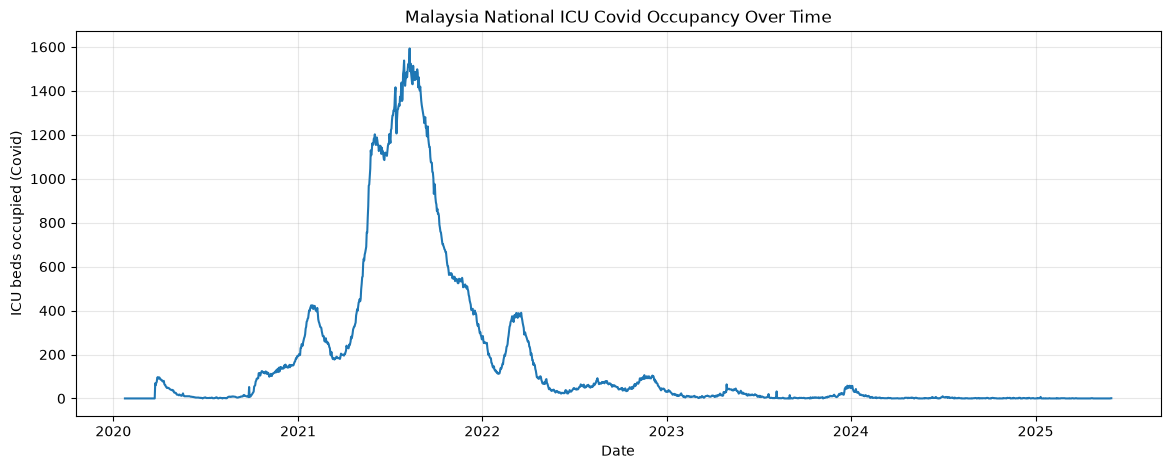

In [15]:
# plot national ICU covid occupancy over the full data range to see waves and trends
plt.figure(figsize=(14,5))
plt.plot(merged['date'], merged['icu_covid'])
plt.title("Malaysia National ICU Covid Occupancy Over Time")
plt.xlabel("Date")
plt.ylabel("ICU beds occupied (Covid)")
plt.grid(alpha=0.3)
plt.savefig("figures/icu_occupancy_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

ICU occupancy shows several distinct waves rather than one continuous trend, a small early bump in 2020, a moderate peak around 2021, then by far the largest wave peaking near 1600 beds around mid-to-late 2021, matching the Delta wave. A smallar secondary peak of about 400 appears in early 2022, likely the Omicron wave, before occupancy drops sharply and stays consistently low from mid-2022 through 2025. This patter suggests each wave after Delta caused progressively less severe ICU demand, likely due to accumulated vaccination and immunity.

### **Cases, Hospital Admissions and ICU Occupancy Over Time**

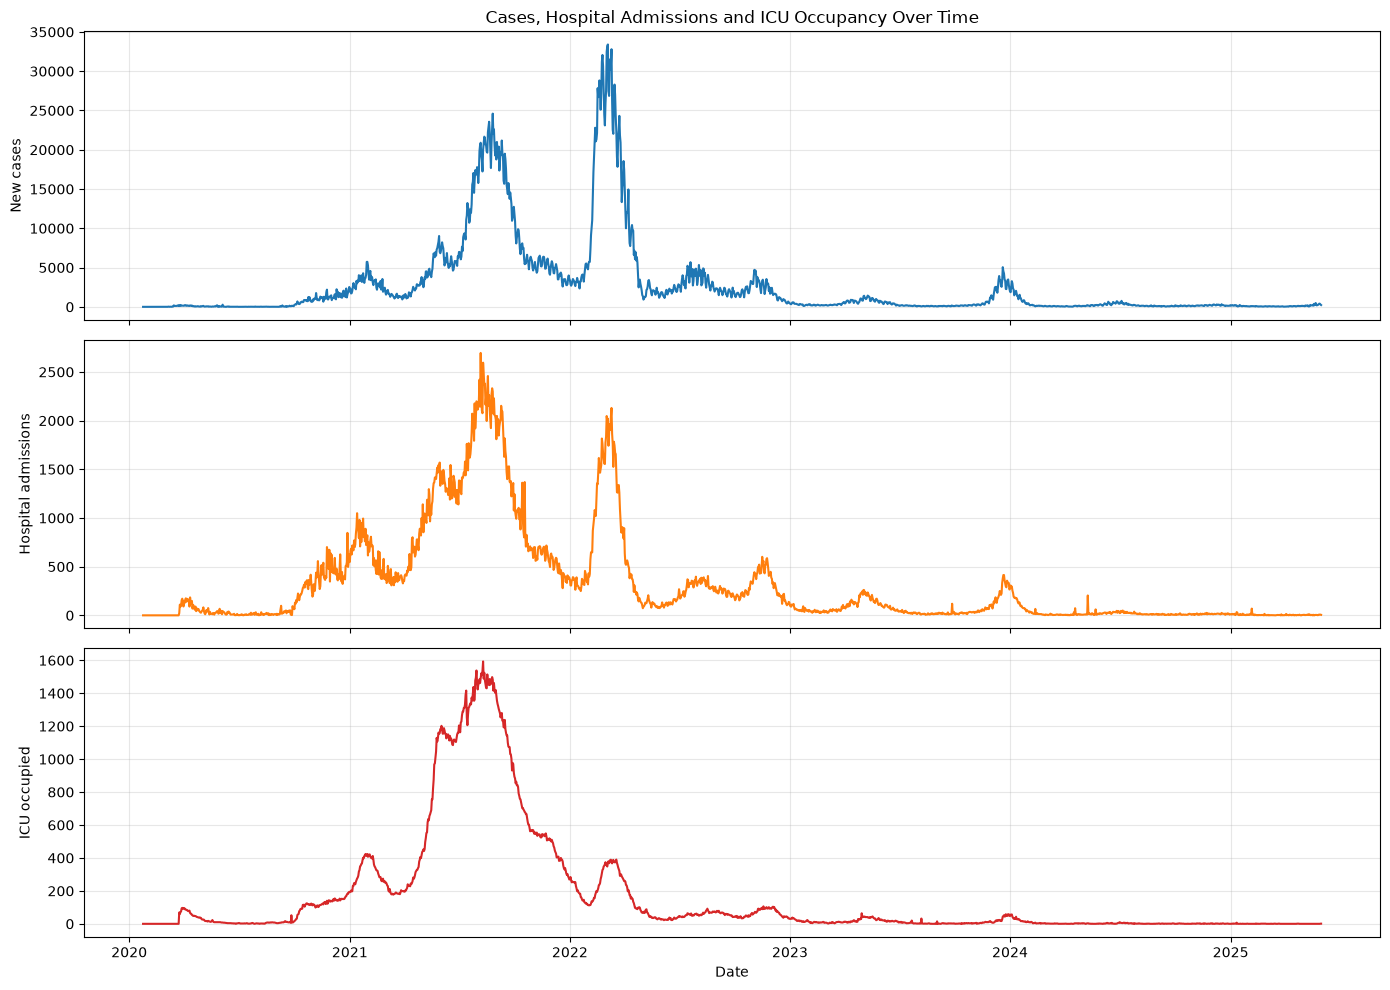

In [16]:
# plot cases, hospital admissions and icu occupancy together to compare timing and lag
fig, axes = plt.subplots(3, 1, figsize=(14,10), sharex=True)

axes[0].plot(merged["date"], merged["cases_new"], color="tab:blue")
axes[0].set_ylabel("New cases")
axes[0].set_title("Cases, Hospital Admissions and ICU Occupancy Over Time")

axes[1].plot(merged["date"], merged["admitted_covid"], color="tab:orange")
axes[1].set_ylabel("Hospital admissions")

axes[2].plot(merged["date"], merged["icu_covid"], color="tab:red")
axes[2].set_ylabel("ICU occupied")
axes[2].set_xlabel("Date")

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figures/cases_hospital_icu_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
# smooth each series with a 7-day rolling average to remove weekday noise, then check lag correlation
cases_smooth = merged["cases_new"].rolling(7).mean()
admitted_smooth = merged["admitted_covid"].rolling(7).mean()
icu_smooth = merged["icu_covid"].rolling(7).mean()

lags = range(0, 22)

cases_vs_admitted = [cases_smooth.corr(admitted_smooth.shift(-lag)) for lag in lags]
cases_vs_icu = [cases_smooth.corr(icu_smooth.shift(-lag)) for lag in lags]

best_admitted_lag = lags[cases_vs_admitted.index(max(cases_vs_admitted))]
best_icu_lag = lags[cases_vs_icu.index(max(cases_vs_icu))]

print(f"cases -> admissions (7-day smoothed): best correlation at lag {best_admitted_lag} days (corr={max(cases_vs_admitted):.3f})")
print(f"cases -> icu (7-day smoothed): best correlation at lag {best_icu_lag} days (corr={max(cases_vs_icu):.3f})")

cases -> admissions (7-day smoothed): best correlation at lag 0 days (corr=0.881)
cases -> icu (7-day smoothed): best correlation at lag 0 days (corr=0.687)


Cases, admissions and ICU occupancy show their strongest correlation at 0 days lag rather than a multi-day delay. One possible explanation is that cases_new reflects a reporting date rather than an infection date, meaning some of the real clinical delay could already be built into when a case is recorded, though this specific explanation was not tested against that data and the true lag may also have varied by wave. The early 2022 wave produced the highest raw case count of the pandemic, over 30,000 daily cases, yet far fewer hospital admissions and ICU cases than the smaller mid-2021 Delta wave. This gap between case volumn and severity is likely explained by Omicron being milder combined with higher vaccination coverage by early 2022.

### **Correlation between Testing, Cases and ICU Occupancy**

In [ ]:
# combine test types into a total testing count
merged["tests_total"] = merged["rtk-ag"] + merged["pcr"]

# compute a simple correlation matrix between testing rate, case counts and icu occupancy
corr_cols = ["tests_total", "cases_new", "icu_covid"]
corr_matrix = merged[corr_cols].corr()
print(corr_matrix)

             tests_total  cases_new  icu_covid
tests_total     1.000000   0.833042   0.716991
cases_new       0.833042   1.000000   0.681681
icu_covid       0.716991   0.681681   1.000000


C:\Users\peish\AppData\Local\Temp\ipykernel_17068\198972661.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged["tests_total"] = merged["rtk-ag"] + merged["pcr"]


In [19]:
# compute test positivity rate, since raw testing volume alone can be a noisy signal
merged["positivity_rate"] = merged["cases_new"] / merged["tests_total"]

corr_cols = ["tests_total", "positivity_rate", "cases_new", "icu_covid"]
corr_matrix = merged[corr_cols].corr()
print(corr_matrix)

                 tests_total  positivity_rate  cases_new  icu_covid
tests_total         1.000000        -0.099152   0.833042   0.716991
positivity_rate    -0.099152         1.000000   0.095813  -0.018035
cases_new           0.833042         0.095813   1.000000   0.681681
icu_covid           0.716991        -0.018035   0.681681   1.000000


C:\Users\peish\AppData\Local\Temp\ipykernel_17068\192766754.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged["positivity_rate"] = merged["cases_new"] / merged["tests_total"]


Total testing volume correlates strongly with both cases and ICU occupancy, but this is likely confounded by testing capacity itself growing over the multi-year period, similar to the shared-trend itself found earlier, rather than reflecting a meaningful relationship. Positivity rate, which is usually a cleaner signal since it partly accounts for testing volume, shows only a weak correlation with cases and virtually none with ICU occupancy at the raw daily level, suggesting it may need smoothing or a different framing to be useful as a feature.

### **ICU-to-Cases Ratio vs Vaccination Coverage Over Time**

C:\Users\peish\AppData\Local\Temp\ipykernel_17068\3521067550.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged["vax_coverage_pct"] = (merged["cumul_full"] / pop_malaysia) * 100
C:\Users\peish\AppData\Local\Temp\ipykernel_17068\3521067550.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged["icu_to_cases_ratio"] = icu_smooth / cases_smooth


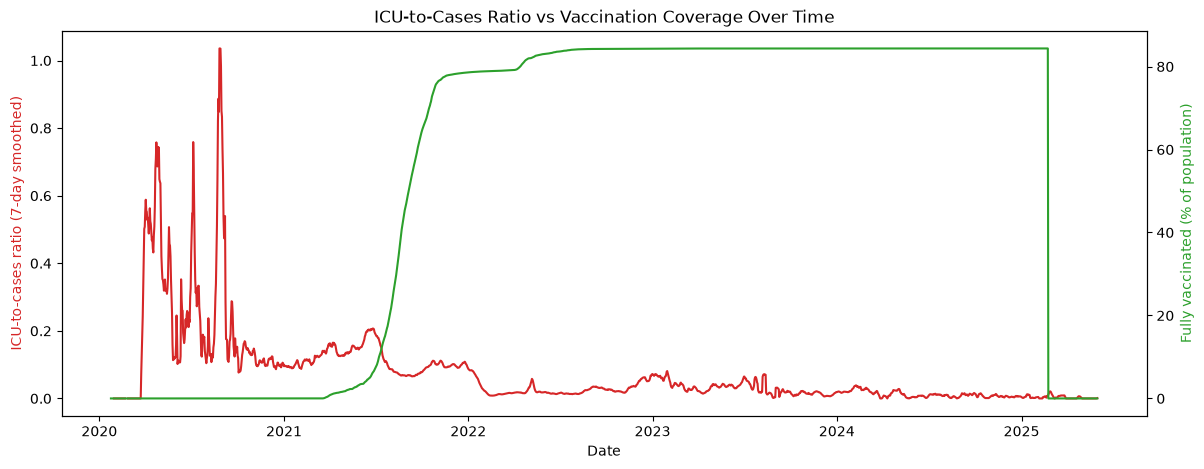

In [21]:
# compute vaccination coverage (% of population fully vaccinated) over time
pop_malaysia = population.loc[population["state"] == "Malaysia", "pop"].values[0]
merged["vax_coverage_pct"] = (merged["cumul_full"] / pop_malaysia) * 100

# compute a smoothed "severity ratio": icu occupancy relative to new cases, using 7-day averages to reduce noise 
cases_smooth = merged["cases_new"].rolling(7).mean()
icu_smooth = merged["icu_covid"].rolling(7).mean()
merged["icu_to_cases_ratio"] = icu_smooth / cases_smooth

# plot vaccination coverage and the icu-to-cases ratio together to see if the ratio drops as coverage rises
fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(merged["date"], merged["icu_to_cases_ratio"], color="tab:red")
ax1.set_ylabel("ICU-to-cases ratio (7-day smoothed)", color="tab:red")
ax1.set_xlabel("Date")

ax2 = ax1.twinx()
ax2.plot(merged["date"], merged["vax_coverage_pct"], color="tab:green")
ax2.set_ylabel("Fully vaccinated (% of population)", color="tab:green")

plt.title("ICU-to-Cases Ratio vs Vaccination Coverage Over Time")
plt.savefig("figures/vax_coverage_vs_icu_ratio.png", dpi=150, bbox_inches="tight")
plt.show()

In [23]:
# check actual cases_new values during the volatile 2020-mid 2021 period
early_period = merged[(merged["date"] >= "2020-03-01") & (merged["date"] <= "2021-06-01")]
print(early_period[["date", "cases_new", "icu_covid", "icu_to_cases_ratio"]].describe())

# specifically look at the days where the ratio spiked highest
top_spikes = merged.nlargest(10, "icu_to_cases_ratio")[["date", "cases_new", "icu_covid", "icu_to_cases_ratio"]]
print("\n", top_spikes)

                      date    cases_new    icu_covid  icu_to_cases_ratio
count                  458   458.000000   458.000000          458.000000
mean   2020-10-15 12:00:00  1265.146288   160.858079            0.209067
min    2020-03-01 00:00:00     0.000000     0.000000            0.000000
25%    2020-06-23 06:00:00    31.000000     8.000000            0.107658
50%    2020-10-15 12:00:00   659.500000   100.500000            0.135031
75%    2021-02-06 18:00:00  1915.250000   225.500000            0.236525
max    2021-06-01 00:00:00  9020.000000  1182.000000            1.035714
std                    NaN  1667.201465   220.732190            0.187105

           date  cases_new  icu_covid  icu_to_cases_ratio
215 2020-08-26        6.0        9.0            1.035714
216 2020-08-27        5.0        8.0            1.035714
217 2020-08-28       10.0        8.0            1.035088
218 2020-08-29       11.0        8.0            0.983333
213 2020-08-24        7.0        8.0            0.887097

The ICU-to-cases ratio was highly volatile before mid-2021 but this is a data artifact, not a real severity signal. On the highest-ratio days, such as August 2020, cases_new was in the single digits (as low as 5-6 per day) while icu_covid still sat around 6-9, a residual from earlier admissions, so dividing by such as a small case count produced an exaggerated, unstab;e ratio. As vaccination coverage climbed from mid-2021 through early 2022, the ratio dropped and stabilized around 0.05 to 0.1, consistent with vaccination reducing the share of cases that progressed to needing ICU care. The apparent drop to zero at the very end of the chart is also not real, it comes from vax.csv ending its reporting in February 2025 and those gaps being filled with 0 of carried forward and should be corrected before this feature is used in modeling.

In [ ]:
# fix the vax coverage artifact found above
import numpy as np

# forward fill vaccination-related columns after vax.csv's last reporting date, instead of leaving them at 0
vax_cols = dfs["vax"].columns.drop("date")
after_vax_end = merged["date"] > vax_end

merged.loc[after_vax_end, vax_cols] = np.nan
merged[vax_cols] = merged[vax_cols].ffill()

# recompute vaccination coverage now that the underlying column is fixed
merged["vax_coverage_pct"] = (merged["cumul_full"] / pop_malaysia) * 100

print(merged.loc[merged["date"] == merged["date"].max(), ["date", "vax_coverage_pct"]])

           date  vax_coverage_pct
1954 2025-05-31          84.36506


### **Key Findings**

1. ICU occupancy shows distinct pandemic waves rather than a steady trend, dominated by one massive Delta-wave peak (~1600 beds) around mid-to-late 2021, with a smaller Omicron-driven peak (~400 beds) in early 2022, and minimal ICU pressure from mid-2022 onward.
2. The early 2022 case wave was the largest by raw case count (over 30,000 daily cases), exceeding the 2021 Delta wave, yet produced far fewer hospital admissions and a much smaller ICU peak, suggesting reduced severity per case.
3. Cases, admissions, and ICU occupancy correlate most strongly at 0 days lag rather than a multi-day delay, though this may partly reflect that case counts are reporting dates rather than true infection dates, and the real lag likely varied between waves.
4. Testing volume correlates strongly with cases and ICU occupancy, but this is likely confounded by testing capacity itself growing over the years. Positivity rate, a cleaner metric in theory, showed almost no raw correlation with ICU occupancy, suggesting it would need smoothing to be a useful feature.
5. The ratio of ICU occupancy to new cases dropped and stabilized as vaccination coverage rose through 2021-2022, consistent with vaccination reducing severe outcomes, though early-pandemic ratio volatility was a data artifact from very low case counts, not a real signal.